<a href="https://colab.research.google.com/github/Noran-lopes/obesity-ml-fiap/blob/main/obesity_ml_fiap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("Obesity.csv")

# =========================
# FEATURE ENGINEERING
# =========================
df["IMC"] = df["Weight"] / (df["Height"] ** 2)

# =========================
# 🔥 REMOÇÃO VARIÁVEIS PROBLEMÁTICAS
# =========================
df_model = df.drop(["Weight", "Height"], axis=1)

# =========================
# ENCODING
# =========================
le_dict = {}

for col in df_model.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le  # salvar encoders

# =========================
# SPLIT
# =========================
X = df_model.drop("Obesity", axis=1)
y = df_model["Obesity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODEL
# =========================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# AVALIAÇÃO
# =========================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# =========================
# SAVE MODEL + ENCODERS
# =========================
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(le_dict, open("encoders.pkl", "wb"))

print("✅ Modelo e encoders salvos!")

Accuracy: 0.9763593380614657
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        56
           1       0.92      0.98      0.95        62
           2       0.99      0.99      0.99        78
           3       0.98      0.98      0.98        58
           4       1.00      1.00      1.00        63
           5       0.98      0.91      0.94        56
           6       0.98      0.98      0.98        50

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423

✅ Modelo e encoders salvos!


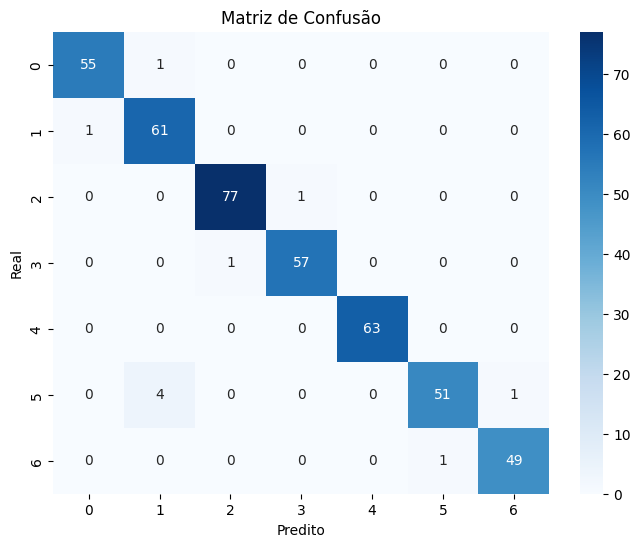

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

In [20]:
pip install streamlit

In [21]:
import streamlit as st
import pickle
import numpy as np

# =========================
# LOAD
# =========================
model = pickle.load(open("model.pkl", "rb"))
encoders = pickle.load(open("encoders.pkl", "rb"))

st.set_page_config(page_title="Predição de Obesidade", layout="centered")

st.title("🧠 Predição de Nível de Obesidade")
st.write("Preencha os dados abaixo:")

# =========================
# INPUTS
# =========================

gender = st.selectbox("Gênero", ["Male", "Female"])
age = st.slider("Idade", 10, 80)

family_history = st.selectbox("Histórico familiar de obesidade", ["yes", "no"])
favc = st.selectbox("Consome comida calórica?", ["yes", "no"])

fcvc = st.slider("Vegetais (1-3)", 1.0, 3.0)
ncp = st.slider("Número de refeições", 1.0, 5.0)

caec = st.selectbox("Lanches entre refeições", ["no", "Sometimes", "Frequently", "Always"])
smoke = st.selectbox("Fuma?", ["yes", "no"])

ch2o = st.slider("Água (litros/dia)", 1.0, 3.0)
scc = st.selectbox("Controla calorias?", ["yes", "no"])

faf = st.slider("Atividade física", 0.0, 5.0)
tue = st.slider("Tempo de tela (h/dia)", 0.0, 10.0)

calc = st.selectbox("Consumo álcool", ["no", "Sometimes", "Frequently", "Always"])

mtrans = st.selectbox(
    "Transporte",
    ["Walking", "Bike", "Public_Transportation", "Automobile", "Motorbike"]
)

# ✅ IMC (input correto)
peso = st.number_input("Peso (kg)", 30.0, 200.0)
altura = st.number_input("Altura (m)", 1.40, 2.20)

imc = peso / (altura ** 2)

# =========================
# PREVISÃO
# =========================
if st.button("Prever"):

    input_dict = {
        "Gender": gender,
        "Age": age,
        "family_history": family_history,
        "FAVC": favc,
        "FCVC": fcvc,
        "NCP": ncp,
        "CAEC": caec,
        "SMOKE": smoke,
        "CH2O": ch2o,
        "SCC": scc,
        "FAF": faf,
        "TUE": tue,
        "CALC": calc,
        "MTRANS": mtrans,
        "IMC": imc
    }

    # =========================
    # ENCODE
    # =========================
    for col in encoders:
        input_dict[col] = encoders[col].transform([input_dict[col]])[0]

    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    prediction = model.predict(input_array)

    st.success(f"✅ Nível de obesidade: {prediction[0]}")

2026-05-29 01:08:43.634 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 01:08:43.639 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 01:08:44.017 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-29 01:08:44.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 01:08:44.032 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 01:08:44.036 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 01:08:44.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [23]:
!streamlit run streamlit_app.py



2026-05-29 01:09:19.215 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.150.226:8501

  Stopping...
  Stopping...
